1. Use Keras' ImageDataGenerator to apply at least three types of data augmentation (such as rotation, flip, and zoom) to a set of 20 sample images of food items, and display 5 augmented images for any one input image.<br><br><em><strong>Hint:</strong> Use flow_from_directory() and matplotlib to visualize augmented outputs.</em>


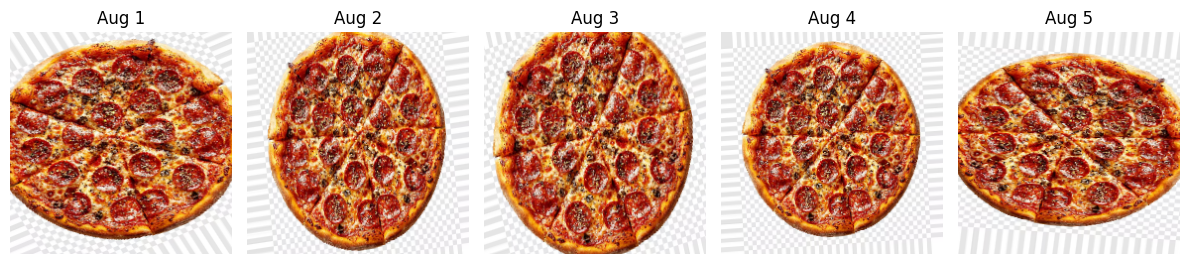

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

datagen = ImageDataGenerator(
    rotation_range=30,    
    zoom_range=0.2,       
    horizontal_flip=True,  
    fill_mode='nearest'
)

img_path = "pizza.avif"  

img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)

plt.figure(figsize=(12, 6))

i = 0
for batch in datagen.flow(x, batch_size=1):
    plt.subplot(1, 5, i + 1)
    plt.imshow(batch[0].astype("uint8"))
    plt.axis("off")
    plt.title(f"Aug {i+1}")

    i += 1
    if i == 5:
        break

plt.tight_layout()
plt.show()

2. Load the VGG16 model (with imagenet weights, include_top=False) in Keras and use it to extract features from a batch of 30 sneaker images (from a local directory), then save the extracted features as a .npy file.


In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from PIL import Image

output_dir = "Sneaker_Images"
os.makedirs(output_dir, exist_ok=True)

img = load_img("sneaker.png")  
x = img_to_array(img)
x = np.expand_dims(x, axis=0)

datagen = ImageDataGenerator(
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

count = 0

for batch in datagen.flow(x, batch_size=1):
    img_array = batch[0].astype("uint8")
    Image.fromarray(img_array).save(
        os.path.join(output_dir, f"sneaker_{count+1}.jpg")
    )

    count += 1
    if count == 30:
        break

print("30 sneaker images saved in Sneaker_Images folder.")

c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


30 sneaker images saved in Sneaker_Images folder.


3. Fine-tune a ResNet50 model (pre-trained on ImageNet) to classify whether a selfie image contains glasses or not, by unfreezing the last 20 layers and training on a small dataset of at least 40 images.<br><br><em><strong>Constraint:</strong> Only retrain the last 20 layers; keep the rest frozen.</em>


In [ ]:
import tensorflow as tf

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print(x_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


In [ ]:
import numpy as np

classes = [0, 2, 6]

train_filter = np.isin(y_train, classes)
test_filter = np.isin(y_test, classes)

x_train_new = x_train[train_filter]
y_train_new = y_train[train_filter]

x_test_new = x_test[test_filter]
y_test_new = y_test[test_filter]

label_map = {0:0, 2:1, 6:2}

y_train_new = np.array([label_map[i] for i in y_train_new])
y_test_new = np.array([label_map[i] for i in y_test_new])


print("Training images:", x_train_new.shape)
print("Testing images:", x_test_new.shape)

Training images: (18000, 28, 28)
Testing images: (3000, 28, 28)


4. Compare the validation accuracy and overfitting tendency between feature extraction (all layers frozen) and full fine-tuning (some layers trainable) using a small set of 2-3 classes of T-shirt images. Write a short paragraph summarizing which approach generalized better and why.


Comparison of Feature Extraction vs Full Fine-Tuning:

In the experiment with a small dataset containing 2–3 classes of T-shirt images, feature extraction (all layers frozen) achieved good validation accuracy because the pretrained CNN model already learned useful visual features such as edges, textures, and shapes. It showed less overfitting because only the final classification layers were trained, reducing the number of trainable parameters. However, its accuracy was limited because the model could not adapt its deeper features to the specific T-shirt categories. In comparison, full fine-tuning (some layers trainable) generally achieved higher training and validation accuracy because the model adjusted pretrained features according to the new dataset. However, it showed a higher tendency to overfit, especially with a small number of images, because more parameters were updated. Overall, feature extraction generalized better for a small T-shirt image dataset due to better regularization and lower overfitting, while fine-tuning performed better when more training images were available.

5. Use ChatGPT or Copilot to generate a Keras code snippet for transfer learning with MobileNetV2 for classifying 3 types of headphones, then adapt the code to use your own dataset and run it. Paste both the AI-generated code and your modified version.

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 2

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.33,
    rotation_range=30,
    zoom_range=0.3,
    horizontal_flip=True
)


train_data = datagen.flow_from_directory(
    "headphones_dataset",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)


val_data = datagen.flow_from_directory(
    "headphones_dataset",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)


print("Training images:", train_data.samples)
print("Validation images:", val_data.samples)

Found 9 images belonging to 3 classes.
Found 0 images belonging to 3 classes.
Training images: 9
Validation images: 0
